In [46]:
### From segmentation framework ###

## OK this is kind of take 3.
## segmentation is hard for dataset BBBC06 because some nuclei are elongated and many are touching

## randomly trying different steps wasn't working and is not really the right approach

## we should have a framework or decision tree type approach that says
## Step 1. if you have xx, then try yy.
## Step 2. If it looks like this, then do that.

## So here is an attempt at attempting to use that framework
## https://chatgpt.com/c/6909e48e-96bc-832b-8c9f-8a4653a0c959

## Libraries
## Load packages
# import glob, os
import skimage
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
# import napari_segment_blobs_and_things_with_membranes as nsbatwm
# import napari_simpleitk_image_processing as nsitk
# import scipy

## set dirs
cwd = Path.cwd()
# Find the first parent that matches the target folder
for p in cwd.parents:
    if p.name == "UCL-Biosciences-Image-Analysis":
        DIR = p
        break
else:
    raise FileNotFoundError("Base directory 'UCL-Biosciences-Image-Analysis' not found in path.")

DATA_DIR = DIR / "input_data" / "BBBC006_v1_images_z_16"


# 2D Segmentation Decisions
Segmentation of 2D bioimages is a decision process, not a single algorithm. Classic (non-deep-learning) methods work well for many fluorescence datasets, but performance depends on contrast, object size, touching rate, and staining consistency. This guide provides a structured workflow and routing logic so users do not jump randomly between filters and thresholds.

The framework follows a simple sequence:

1. Define object and constraints
2. Preprocess (illumination, noise, contrast)
3. Extract foreground
4. Generate seeds (if instances touch)
5. Separate objects (watershed)
6. Filter and correct
7. Quality-check and iterate

Each stage has clear decision points. If the required conditions are not met, the user branches appropriately (e.g. improve contrast or adjust seeding rather than forcing a failing threshold). The aim is to reduce guesswork and keep workflows simple and reproducible.

This is not a code cookbook. It is a method to choose the right steps and avoid unnecessary complexity. If the image fails early checks and cannot be rescued with standard preprocessing, acquisition improvements should be prioritised rather than stacking more operations.

### 1. Define object and constraints
this is for the user to understand the data and what the data mean for the analysis

## What to record up front ##

Object: nuclei / whole cells / sub-objects

Imaging: fluorescence / brightfield; channels used for object vs boundary

Size range: expected pixel area or diameter. Calculate:

- effective_px_size = camera_px_size / magnification
- effective_px_size_after_binning = effective_px_size × bin_factor
- expected_pixel_diameter = physical_diameter / effective_px_size_after_binning

Touching frequency: low / medium / high

Shape: round / elongated / irregular

Signal reliability: consistent / variable (across field, across batch)

Error tolerance: more acceptable to miss objects or to over-split?

## Why this matters ##
Size → filters and distance-transform parameters

Touching → need for seeds and watershed

Shape → distance peaks vs erosion vs skeleton seeds

Signal quality → global vs adaptive thresholding

Error preference → threshold and watershed aggressiveness

# If missing information
If you cannot estimate size and touching rate, inspect ~50 fields and measure.

If you do not know whether contrast is stable, check across plates/batches.

## Stop rule ##
If contrast is fundamentally insufficient after basic preprocessing, do not proceed. Fix staining/illumination.


(520, 696)
we have  14  images
each image has  (520, 696)  pixels


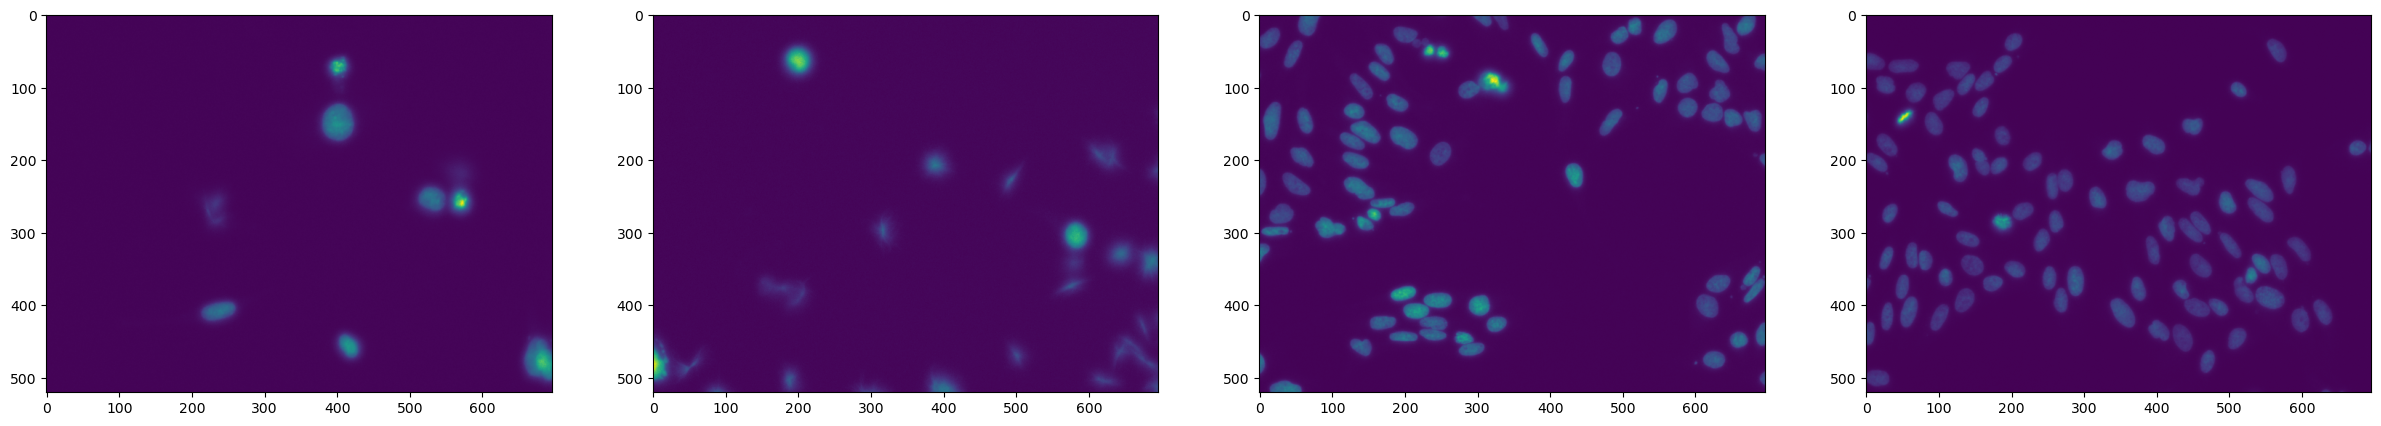

In [2]:
### Read in data
# List files
files = sorted(DATA_DIR.glob("*_w1*.tif"))[ :14]
files

### for a list of tifs
images = [ ]
for file in files:
    images.append(skimage.io.imread(file))
# skimage.io.imread_collection(files)

print(images[0].shape)
print('we have ', len(images), ' images')
print('each image has ', images[0].shape, ' pixels')

fig,ax = plt.subplots(1, 4, figsize = (30, 60) )
for i in range(0,4):
    ax[i].imshow(images[i])

## when setting up the analysis, we will use one image at a time, defined here:
img = images[3]

## Fill in for your dataset

We are working with this dataset: https://bbbc.broadinstitute.org/BBBC006. Using specifically plane 16, which is in focus, and w1 (Hoechst 33342 stain for DNA)

**Object**: Nuclei (primary). Whole-cell possible via phalloidin.

**Imaging**: Fluorescence, DAPI/Hoechst (w1) + phalloidin (w2)

**Size range**: 
- U2OS cell nuclei ~16um width and 23um length. (https://pmc.ncbi.nlm.nih.gov/articles/PMC4227890/).
- Pixel size of the camera is 6.45um and magnification is 20x, meaning each pixel is 6.45um/20 = 0.3225.  The data are binned 2x, which means each (super) pixel is 0.645um
- So we expect nuclei to be 16/.645 x 23/.645 ~ 25 x 36 pixels.

**Touching frequency**: medium. Looking at raw images shows many, but not all, objects are touching.

**Shape**: Many round, some elongated

**Signal reliability**: Using in-focus, signal is good.

**Primary failure to avoid**: oversegmenting elongated nuclei, undersegmenting touching nuclei.



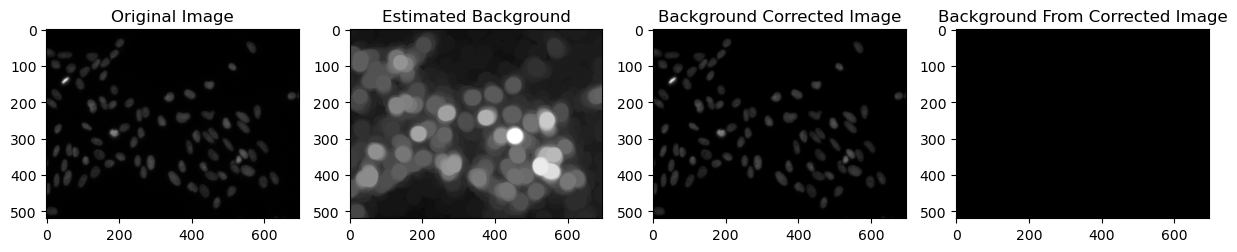

In [3]:
### 2. Pre-processing 
# i. Correct uneven background.
# contrast between objects and background is easier to identify when background is even

# ii. Denoise. 
# use median or gaussian filter to reduce noise and make contrasts more stable

# iii. Normalise intensity
# Brightness varies among images. Normalise so steps are applicable across images.

# iv. Visualise
# does it look sensible?


### i. Correct background
# use rolling ball algorithm from skimage
from skimage import restoration, morphology

# estimate background
background = morphology.opening(img, morphology.disk(20)) # radius > size of objects to be detected
# subtract background from original image
img_bg_corrected = img - background
# ensure no negative values
img_bg_corrected = np.clip(img_bg_corrected, 0, None)
bg_corrected = morphology.opening(img_bg_corrected, morphology.disk(20))

# Visualise
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(background, cmap='gray')
ax[1].set_title('Estimated Background')
ax[2].imshow(img_bg_corrected, cmap='gray')
ax[2].set_title('Background Corrected Image')
ax[3].imshow(bg_corrected, cmap='gray')
ax[3].set_title('Background From Corrected Image')
plt.show()

# Background should be smooth (panel 2) and not show cell-like structure
# Background corrected image (panel 3) should have improved contrast and nuclei should not be hollow
# Background from corrected image (panel 4) should be consistant and ideally consistently dark 

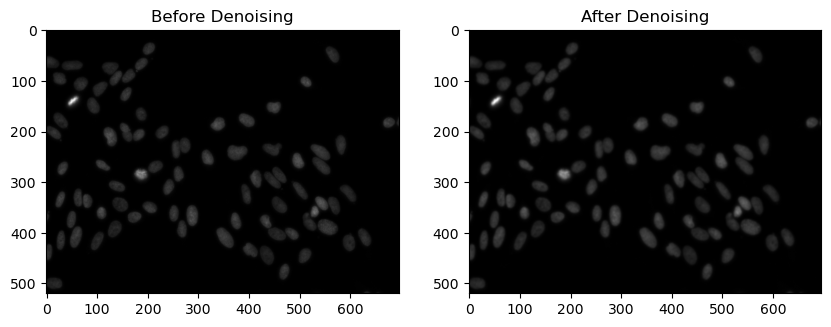

In [4]:
# Pre-processing ii. Denoise
# Apply Gaussian filter
from scipy.ndimage import gaussian_filter
img_denoised = gaussian_filter(img_bg_corrected, sigma=1)
# Visualise
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_bg_corrected, cmap='gray')
ax[0].set_title('Before Denoising')
ax[1].imshow(img_denoised, cmap='gray')
ax[1].set_title('After Denoising')
plt.show()

# Denoised image (panel 2) should have reduced noise while preserving nuclei structure


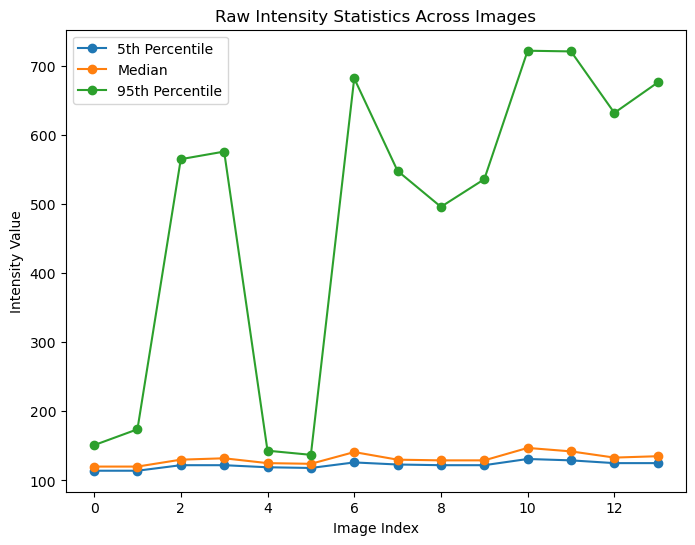

In [5]:
# Pre-processing iii. Normalise intensity
# normalisation needed if exposure varies among images

# here we compare at median, 5th and 95th percentiles of each image
raw_intensity_stats = []
for image in images:
    p5 = np.percentile(image, 5)
    p95 = np.percentile(image, 95)
    median = np.median(image)
    raw_intensity_stats.append((p5, median, p95))    
# Convert to numpy array for easier plotting
raw_intensity_stats = np.array(raw_intensity_stats)

# Plot raw intensity stats
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(raw_intensity_stats[:, 0], 'o-', label='5th Percentile')
ax.plot(raw_intensity_stats[:, 1], 'o-', label='Median')
ax.plot(raw_intensity_stats[:, 2], 'o-', label='95th Percentile')
ax.set_xlabel('Image Index')
ax.set_ylabel('Intensity Value')
ax.set_title('Raw Intensity Statistics Across Images')
ax.legend()
plt.show()

# in this case, the median brightness is similar across images
# so we don't normalise


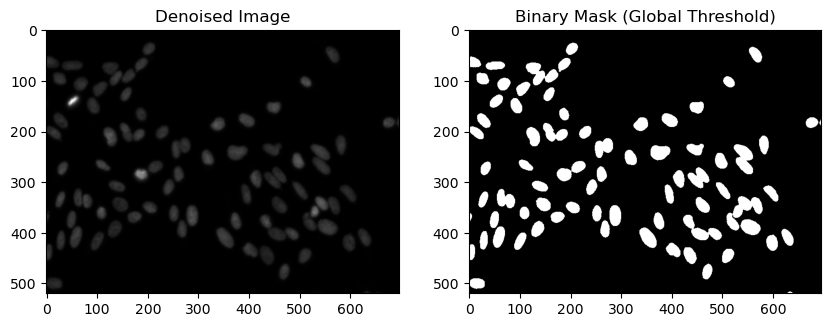

In [13]:
### Extract Foreground
# create a binary mask, with objects as 1 and background as 0

# here you could use a global threshold which is applied across the whole image
# or an adaptive threshold which calculates a local threshold for each pixel based on its neighbourhood

# because we have reduced background noise, we can try a global threshold first

from skimage.filters import threshold_otsu
# Calculate global threshold using Otsu's method
global_thresh = threshold_otsu(img_denoised) # this would change if image was normalised
# Create binary mask
binary_mask = img_denoised > global_thresh
# Visualise
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_denoised, cmap='gray')
ax[0].set_title('Denoised Image')
ax[1].imshow(binary_mask, cmap='gray')
ax[1].set_title('Binary Mask (Global Threshold)')
plt.show()

# Binary mask (panel 2) should show clear separation of nuclei from background
# has it caught even the dimmest nuclei?

## 4. Generate Seeds
Seeding forces the algorithm to start one region per object. Without seeds, touching nuclei merge and thresholding gives blobs, not individual objects. Seeds tell watershed “split here”.

A seed is a single marker pixel or small region placed inside each object. Watershed then grows each seed outward until object boundaries meet.

### Main seeding options (non-DL)

1) *Distance-transform peaks (default)*

Compute distance inside mask → peaks ≈ nucleus centres. Works when nuclei roughly round. Tunable through min distance, and h-max. We generally use this first.

2) *Morphological erosion seeds*

Erode mask to break touches, label components, then dilate seeds back. Robust in dense fields. Risks missing small/faint nuclei if erosion too strong.

3) *LoG (Laplacian-of-Gaussian) blob seeds*

Detect bright blobs directly on intensity image. Good when mask imperfect or nuclei elongated. Needs σ chosen to match object size.

4) *Manual or semi-manual* (rare)

For quality control or difficult edge cases only.

### How to choose
Round nuclei, good mask-        	Distance peaks

Crowded nuclei that stay fused -	Erode mask then seed

Mask imperfect, variable shapes -  	LoG blobs

Very faint nuclei -             	Lower threshold + DT, or small erosion

### Quality targets

- 1 seed per nucleus
- Few extras (filtered by later size rules)
- Rare doubles ok (watershed can merge small ones)
- No seeds in background

Keep it simple: start with distance-transform peaks. Only switch if failure mode is clear and consistent.

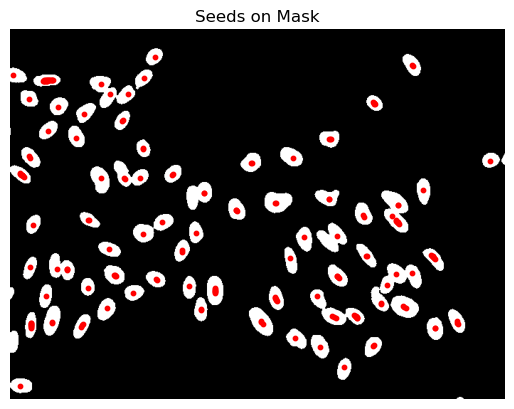

In [21]:
# our mask is pretty good, not to crowded and only some are touching
# so we will start with distance-based seeds

### Generate seeds with distance transform
from scipy import ndimage as ndi
from skimage import morphology, feature, measure

# Distance transform inside mask
# this gives each pixel a value based on its distance to the nearest background pixel
distance = ndi.distance_transform_edt(binary_mask)

# suppress tiny spurious peaks (tune h ≈ 1–3 px)
distance_h = morphology.h_maxima(distance, h=2)

# peak_local_max now returns coordinates only
coords = feature.peak_local_max(
    distance_h,
    footprint=morphology.disk(5),  # adjust 3–7
)

# Create empty seed mask
seeds = np.zeros_like(binary_mask, dtype=np.int32)

# Mark seeds at those coordinates
for i, (r, c) in enumerate(coords, start=1):
    seeds[r, c] = i

seeds = measure.label(seeds)

# Visualise seeds
plt.imshow(binary_mask, cmap='gray')
ys, xs = np.where(seeds > 0)
plt.scatter(xs, ys, s=10, c='red')
plt.title("Seeds on Mask")
plt.axis('off')
plt.show()


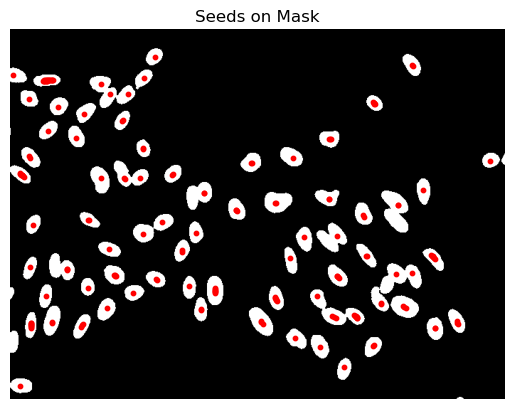

In [22]:
### not great. lots of objects have multiple seeds

# increasing h in h_maxima to suppress more peaks
# increasing disc in footprint to require larger separation between peaks

# suppress tiny spurious peaks
distance_h = morphology.h_maxima(distance, h=4)

# peak_local_max now returns coordinates only
coords = feature.peak_local_max(
    distance_h,
    footprint=morphology.disk(7),  # adjust 3–7
)

# Create empty seed mask
seeds = np.zeros_like(binary_mask, dtype=np.int32)

# Mark seeds at those coordinates
for i, (r, c) in enumerate(coords, start=1):
    seeds[r, c] = i

seeds = measure.label(seeds)

# Visualise seeds
plt.imshow(binary_mask, cmap='gray')
ys, xs = np.where(seeds > 0)
plt.scatter(xs, ys, s=10, c='red')
plt.title("Seeds on Mask")
plt.axis('off')
plt.show()

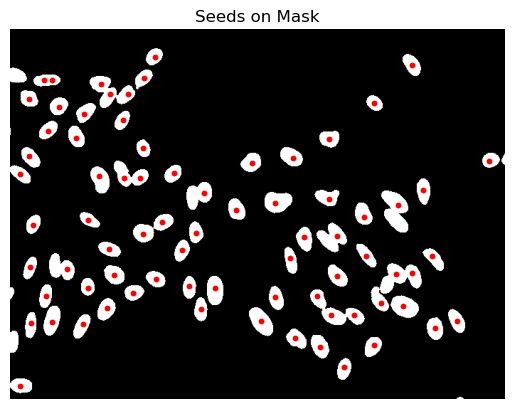

In [32]:
# still no good.
# we will try setting the min_distance parameter in peak_local_max

# suppress tiny spurious peaks
distance_h = morphology.h_maxima(distance, h=3)

# peak_local_max now returns coordinates only
coords = feature.peak_local_max(
    distance_h,
    footprint=morphology.disk(5),  # adjust 3–7
    min_distance=10 # < half expected diameter
)

# Create empty seed mask
seeds = np.zeros_like(binary_mask, dtype=np.int32)

# Mark seeds at those coordinates
for i, (r, c) in enumerate(coords, start=1):
    seeds[r, c] = i

seeds = measure.label(seeds)

# Visualise seeds
plt.imshow(binary_mask, cmap='gray')
ys, xs = np.where(seeds > 0)
plt.scatter(xs, ys, s=10, c='red')
plt.title("Seeds on Mask")
plt.axis('off')
plt.show()

# by setting min_distance we have got a better distribution of seeds
# it is not perfect
# one nucleus has two seeds
# a few touching nuclei still have only one seed
# but overall it is much improved

# we will proceed with these seeds for watershed segmentation
# and try to improve segmentation with post-processing

(np.float64(-0.5), np.float64(695.5), np.float64(519.5), np.float64(-0.5))

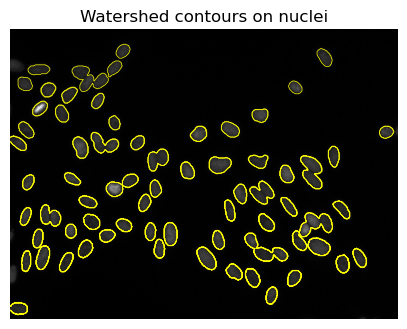

In [37]:
# 5. Separate objects using watershed segmentation
# Perform watershed segmentation to separate touching objects in a binary mask 
# using distance transform and predefined seeds.

from skimage.segmentation import watershed

# Apply watershed segmentation
labels = watershed(-distance, seeds, mask=binary_mask)

# Visualise segmentation showing boundaries
from skimage.segmentation import find_boundaries

bound = find_boundaries(labels, mode='outer')

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')          # original or background-corrected
plt.contour(labels, colors='yellow', linewidths=0.5)
plt.title("Watershed contours on nuclei")
plt.axis('off')

# again this looks sensible
# but we will need to correct errors



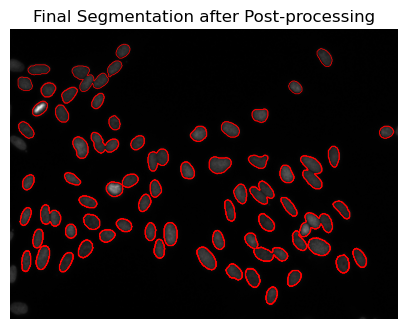

In [41]:
# 6. Post-process segmentation to correct errors
# we want to correct nuclei that are:
# - oversegmented (split into multiple parts)
# - undersegmented (merged together)
# - remove nuclei touching the border (these are not complete)

from skimage import measure, filters, segmentation

# remove nuclei touching the border
labels_cleared = segmentation.clear_border(labels)

# remove small objects, including over segmentation fragments
from skimage.morphology import remove_small_objects
labels_no_small = remove_small_objects(labels_cleared, min_size=150)

# Visualise final segmentation
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')          # original or background-corrected
plt.contour(labels_no_small, colors='red', linewidths=0.5)
plt.title("Final Segmentation after Post-processing")
plt.axis('off')
plt.show()

# we don't have any nuclei touching the border or tiny fragments
# final problem is the undersegmented nuclei

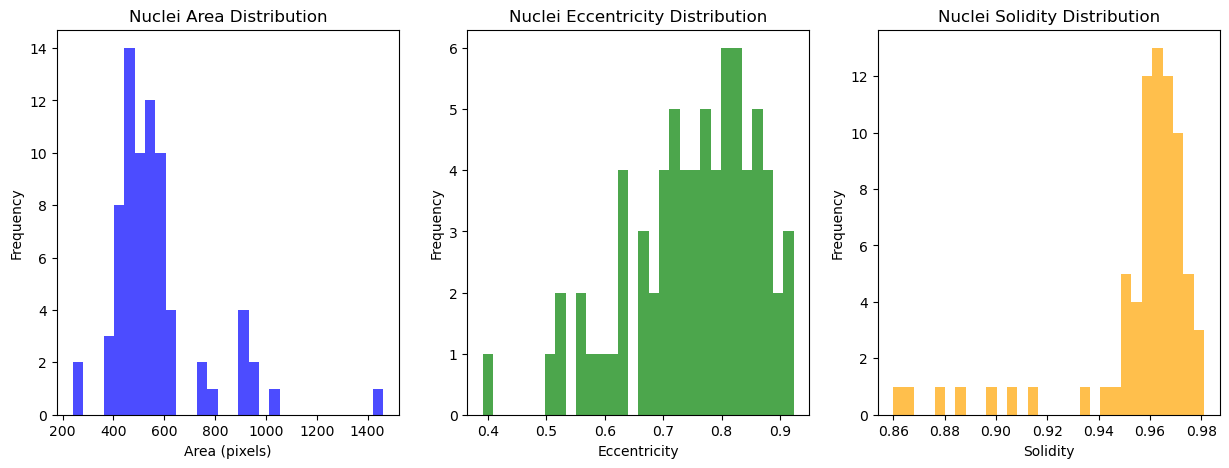

In [54]:
### Undersegmented nuclei
# we can try to identify these based on shape and size
# get properties: label, size, shape (e.g., eccentricity, solidity)
properties = measure.regionprops_table(labels_no_small,
                                       properties=['label',
                                                   'area',
                                                   'eccentricity',
                                                   'solidity'])
properties = pd.DataFrame(properties)

# define thresholds for undersegmentation based on size and shape distributions
# plot histograms
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(properties['area'], bins=30, color='blue', alpha=0.7)
ax[0].set_title('Nuclei Area Distribution')
ax[0].set_xlabel('Area (pixels)')
ax[0].set_ylabel('Frequency')
ax[1].hist(properties['eccentricity'], bins=30, color='green', alpha=0.7)
ax[1].set_title('Nuclei Eccentricity Distribution')
ax[1].set_xlabel('Eccentricity')
ax[1].set_ylabel('Frequency')
ax[2].hist(properties['solidity'], bins=30, color='orange', alpha=0.7)
ax[2].set_title('Nuclei Solidity Distribution')
ax[2].set_xlabel('Solidity')
ax[2].set_ylabel('Frequency')
plt.show()


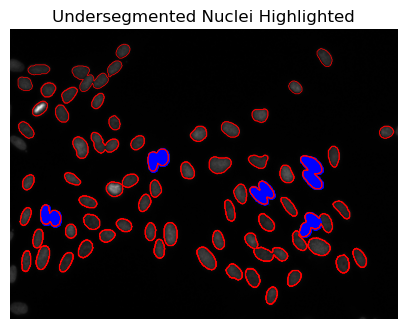

In [63]:
# based on the distributions, the undersegmented nuclei will be
# - larger than average size
# - less elongated (higher eccentricity)
# - less solid (lower solidity)
size_thresh = properties['area'].mean() + ( 2 * properties['area'].std() )
eccentricity_thresh = 0.5
solidity_thresh = properties['solidity'].mean() - (2 * properties['solidity'].std() )

# list to hold labels of undersegmented nuclei
undersegmented_labels = []

# identify undersegmented nuclei
for _, row in properties.iterrows():
    if (row['area'] > size_thresh or
        # row['eccentricity'] < eccentricity_thresh or
        row['solidity'] < solidity_thresh):
        undersegmented_labels.append(row['label'])

# Visualise undersegmented nuclei
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')          # original or background-corrected
plt.contour(labels_no_small, colors='red', linewidths=0.5)
for label in undersegmented_labels:
    coords = np.array(np.where(labels_no_small == label)).T
    plt.scatter(coords[:, 1], coords[:, 0], s=1, c='blue')
plt.title("Undersegmented Nuclei Highlighted")
plt.axis('off')
plt.show()
